# Команда 12. Смирнова М., Дворяшина И., Шумакова В., Шилкова А.

# Импорты библиотек

In [3]:
# Стандартные библиотеки Python
import json
import re

# Сторонние библиотеки
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Чтение данных

In [4]:
# Cкачиваем данные
data_url = f'https://drive.google.com/uc?export=download&id=1s8v3bwLuXzV1o6j5XOyFcbMC0bF4wntN'
output = 'data.csv'
gdown.download(data_url, output, quiet=False)
df = pd.read_csv('data.csv')

Downloading...
From: https://drive.google.com/uc?export=download&id=1s8v3bwLuXzV1o6j5XOyFcbMC0bF4wntN
To: /content/data.csv
100%|██████████| 2.79M/2.79M [00:00<00:00, 11.4MB/s]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                28000 non-null  object 
 1   start_trial_date       28000 non-null  object 
 2   city                   27692 non-null  object 
 3   device                 28000 non-null  object 
 4   source                 28000 non-null  object 
 5   favourite_genre        20048 non-null  object 
 6   avg_min_watch_daily    28000 non-null  float64
 7   number_of_days_logged  28000 non-null  int64  
 8   churn                  28000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.9+ MB


In [6]:
# Проверка наличия пустых значений
print("Пропуски в данных: \n", df.isna().sum())

Пропуски в данных: 
 user_id                     0
start_trial_date            0
city                      308
device                      0
source                      0
favourite_genre          7952
avg_min_watch_daily         0
number_of_days_logged       0
churn                       0
dtype: int64


## Пропуски в данных обнаружены у признака 'city' (308) и 'favourite_genre' (7952)

In [7]:
df.describe()

,avg_min_watch_daily,number_of_days_logged,churn
count,28000.000000,28000.00000,28000.000000
mean,7.812663,1.88600,0.789286
std,7.739760,1.48293,0.407823
min,0.000181,1.00000,0.000000
25%,2.521966,1.00000,1.000000
50%,5.419012,1.00000,1.000000
75%,10.487946,2.00000,1.000000
max,80.072401,7.00000,1.000000


In [8]:
df.describe(include = 'object')

,user_id,start_trial_date,city,device,source,favourite_genre
count,28000,28000,27692,28000,28000,20048
unique,28000,28,9,4,3,5
top,86fc83b2-01e3-4f9a-9bd6-e8065abc029e,2024-02-28,Moscow,web,performance,drama
freq,1,1103,8736,17752,14540,4928


In [9]:
print("Уникальные значения категориального признака city: ", df['city'].unique())
print("Уникальные значения категориального признака device: ", df['device'].unique())
print("Уникальные значения категориального признака source: ", df['source'].unique())
print("Уникальные значения категориального признака favourite_genre: ", df['favourite_genre'].unique())

Уникальные значения категориального признака city:  ['St Petersburg' 'Other' 'Ufa' 'Moscow' 'Samara' 'Krasnodar'
 'Yekaterinburg' 'Novosibirsk' 'Voronezh' nan]
Уникальные значения категориального признака device:  ['ios' 'web' 'smarttv' 'android']
Уникальные значения категориального признака source:  ['performance' 'seo' 'organic']
Уникальные значения категориального признака favourite_genre:  ['drama' 'criminal' 'thriller' 'comedy' nan 'action']


# Чистка данных

In [10]:
# Преобразование дат в datetime
df['start_trial_date'] = pd.to_datetime(df['start_trial_date'])

# Замена NaN на "Unknown"
df['city'] = df['city'].fillna('Unknown')
df['favourite_genre'] = df['favourite_genre'].fillna('Unknown')

# Feature Engineering
# Создание новой колонки день недели начала триала
df['trial_start_day_of_week'] = df['start_trial_date'].dt.dayofweek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  28000 non-null  object        
 1   start_trial_date         28000 non-null  datetime64[ns]
 2   city                     28000 non-null  object        
 3   device                   28000 non-null  object        
 4   source                   28000 non-null  object        
 5   favourite_genre          28000 non-null  object        
 6   avg_min_watch_daily      28000 non-null  float64       
 7   number_of_days_logged    28000 non-null  int64         
 8   churn                    28000 non-null  int64         
 9   trial_start_day_of_week  28000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(5)
memory usage: 2.0+ MB


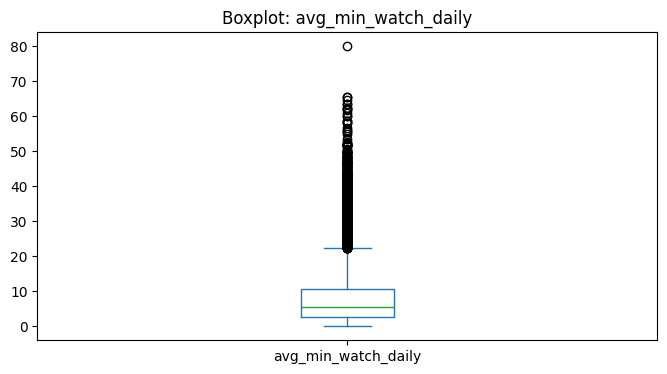

In [11]:
# Построение боксплота распределения и аномалии в данных о среднем времени просмотра
plt.figure(figsize=(8, 4))
df["avg_min_watch_daily"].plot(kind="box")
plt.title("Boxplot: avg_min_watch_daily")
plt.show()

In [12]:
# Расчет процентилей
percentiles = df['avg_min_watch_daily'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Процентили времени просмотра:")
print(percentiles)

Процентили времени просмотра:
0.500     5.419012
0.750    10.487946
0.900    18.095907
0.950    23.691268
0.990    36.007353
0.999    51.902463
Name: avg_min_watch_daily, dtype: float64


Поскольку 80 минут (максимальное значение) - адекватное время просмотра, и в целом для стриминга возможно скошенное распределение, принято решение не проводить очистку от выбросов и работать с исходными данными, чтобы не потерять полезную информацию для анализа конверсии

# Построение диаграмм категориальных признаков для анализа распределение данных

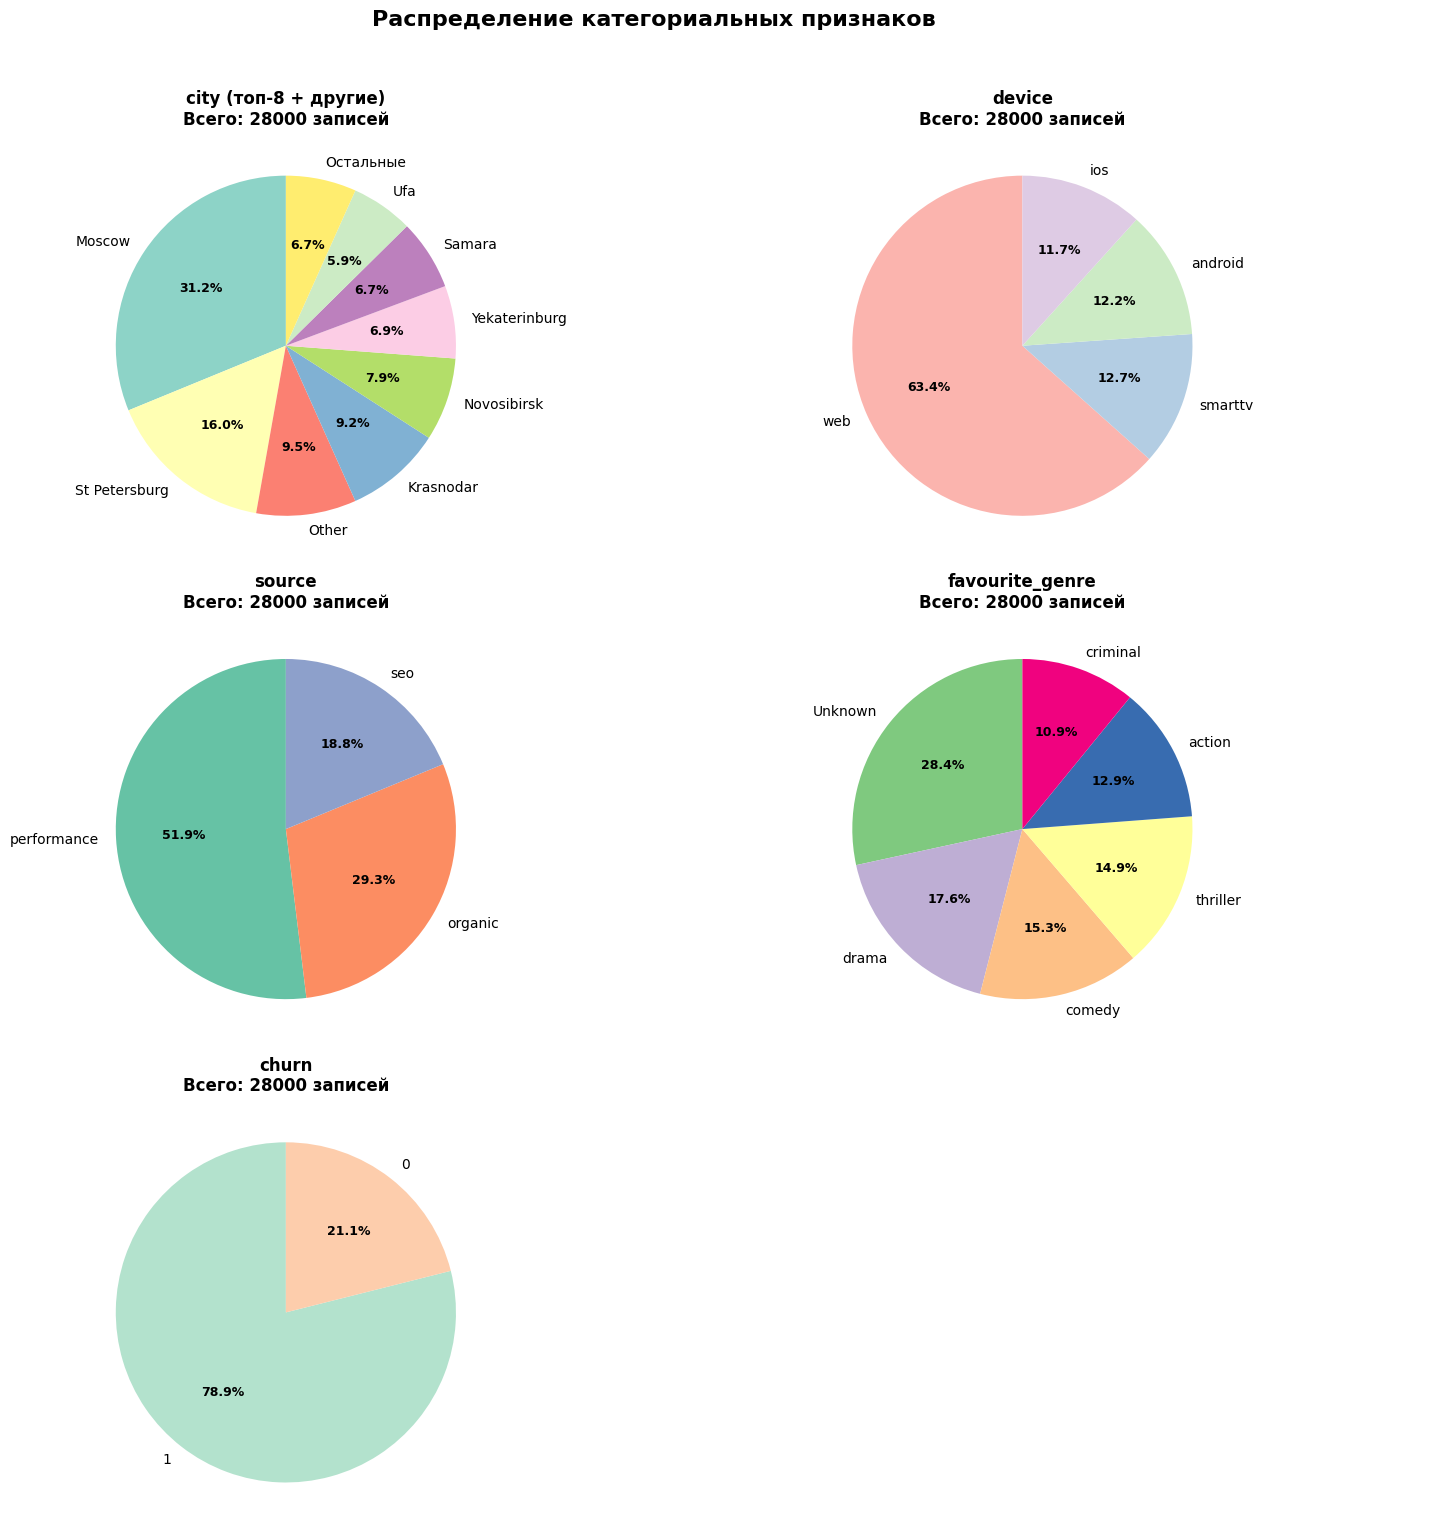

In [13]:
# Определяем категориальные признаки
categorical_columns = ['city', 'device', 'source', 'favourite_genre', 'churn']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

color_palettes = [
    plt.cm.Set3,
    plt.cm.Pastel1,
    plt.cm.Set2,
    plt.cm.Accent,
    plt.cm.Pastel2
]

for i, col in enumerate(categorical_columns):
    if i < len(axes):
        ax = axes[i]

        # Получаем данные
        value_counts = df[col].value_counts()
        total = len(df[col])

        # Если уникальных значений много, показываем топ-8
        if len(value_counts) > 8:
            top_values = value_counts.head(8)
            others_count = value_counts[8:].sum()
            if others_count > 0:
                top_values['Остальные'] = others_count
            title_suffix = " (топ-8 + другие)"
        else:
            top_values = value_counts
            title_suffix = ""

        n_colors = len(top_values)
        if i < len(color_palettes):
            colors = color_palettes[i](np.linspace(0, 1, max(n_colors, 8)))
        else:
            colors = plt.cm.tab20c(np.linspace(0, 1, n_colors))

        colors = colors[:n_colors]

        wedges, texts, autotexts = ax.pie(top_values.values,
                                          labels=top_values.index.astype(str),
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          colors=colors)

        ax.set_title(f'{col}{title_suffix}\nВсего: {total} записей',
                    fontsize=12, fontweight='bold')

        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontsize(9)
            autotext.set_fontweight('bold')

for i in range(len(categorical_columns), len(axes)):
    axes[i].axis('off')

plt.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Все данные выглядят адекватно**

# Построение диаграмм числовых признаков для анализа распределение данных

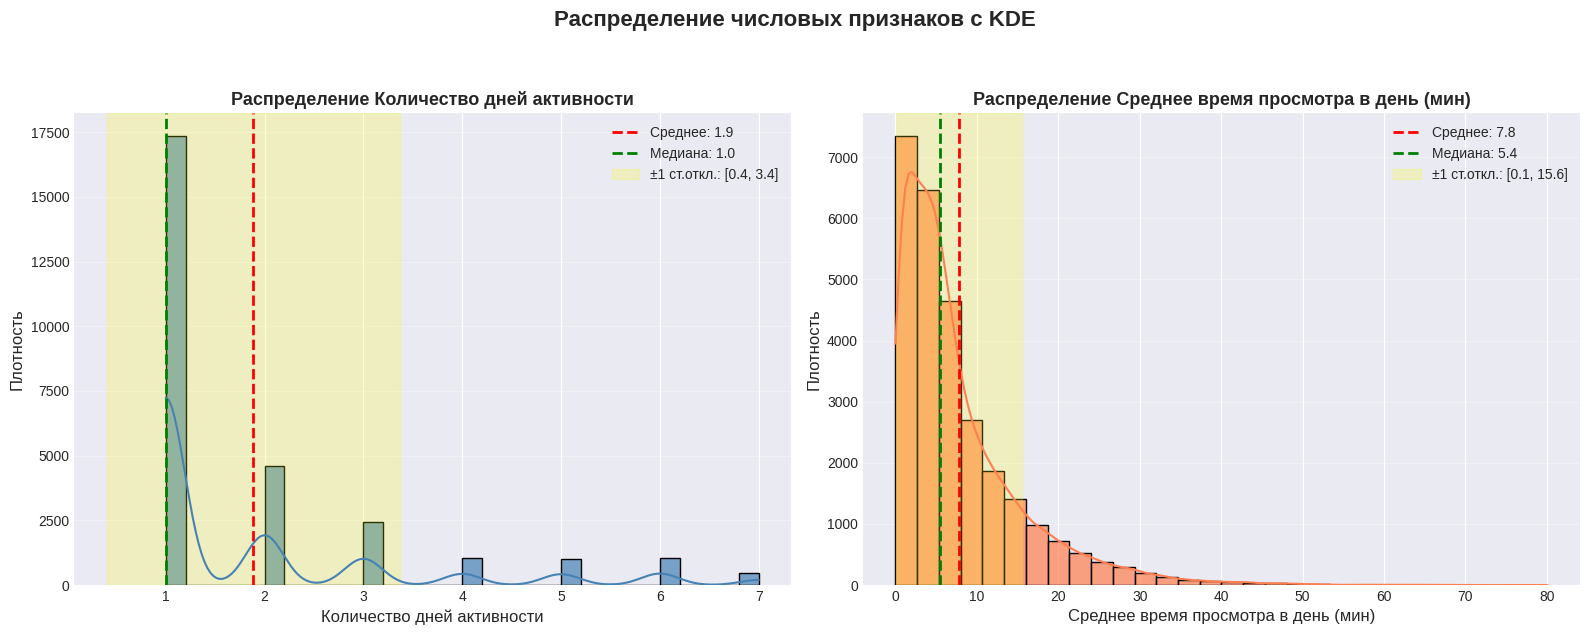


number_of_days_logged:

Асимметрия: 1.854 (сильно скошенное)
Эксцесс: 2.616

avg_min_watch_daily:

Асимметрия: 2.020 (сильно скошенное)
Эксцесс: 5.693


In [14]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Распределение числовых признаков с KDE', fontsize=16, fontweight='bold', y=1.05)

numeric_features = ['number_of_days_logged', 'avg_min_watch_daily']

colors = ['steelblue', 'coral']

for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    ax = axes[idx]

    sns.histplot(data=df, x=feature, bins=30,
                 kde=True, color=color, edgecolor='black', alpha=0.7, ax=ax)

    mean_val = df[feature].mean()
    median_val = df[feature].median()
    std_val = df[feature].std()

    feature_names = {
        'number_of_days_logged': 'Количество дней активности',
        'avg_min_watch_daily': 'Среднее время просмотра в день (мин)'
    }

    feature_name = feature_names.get(feature, feature)
    ax.set_title(f'Распределение {feature_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)

    # Добавляем линии для среднего и медианы
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Среднее: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
               label=f'Медиана: {median_val:.1f}')

    # Добавляем область ±1 стандартное отклонение
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='yellow',
               label=f'±1 ст.откл.: [{mean_val-std_val:.1f}, {mean_val+std_val:.1f}]')

    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for feature in numeric_features:
    print(f"\n{feature}:\n")

    # Асимметрия и эксцесс
    skewness = df[feature].skew()
    kurtosis = df[feature].kurtosis()

    skewness_interpretation = "симметричное" if abs(skewness) < 0.5 else \
                             "умеренно скошенное" if abs(skewness) < 1 else \
                             "сильно скошенное"

    print(f"Асимметрия: {skewness:.3f} ({skewness_interpretation})")
    print(f"Эксцесс: {kurtosis:.3f}")


**Все данные выглядят адекватно**

# Построение тепловой диаграммы, чтобы найти линейные зависимости между признаками

In [15]:
# Сначала сделаем one-hot преобразование категориальных признаков
categorical_cols = ['city', 'device', 'source', 'favourite_genre']
data_encoded = pd.get_dummies(df, columns=categorical_cols)

print(data_encoded.head())

                                user_id start_trial_date  avg_min_watch_daily  \
0  d1b6ef34-1991-452a-8c39-c83c0d5805fe       2024-02-01             2.076642   
1  f1bf2396-73d8-461e-a775-9f068bd99326       2024-02-01             5.101392   
2  ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28       2024-02-01             2.906597   
3  b0195e96-af2e-4ac3-8f60-26b8d862af84       2024-02-01             2.702388   
4  a208985a-7244-4291-8d38-64c8141e27b2       2024-02-01            10.237305   

   number_of_days_logged  churn  trial_start_day_of_week  city_Krasnodar  \
0                      4      1                        3           False   
1                      1      1                        3           False   
2                      1      1                        3           False   
3                      6      0                        3           False   
4                      1      1                        3           False   

   city_Moscow  city_Novosibirsk  city_Other  ...  devic

In [16]:
# Удалим колонку 'user_id', чтобы не мешала анализу
del data_encoded['user_id']

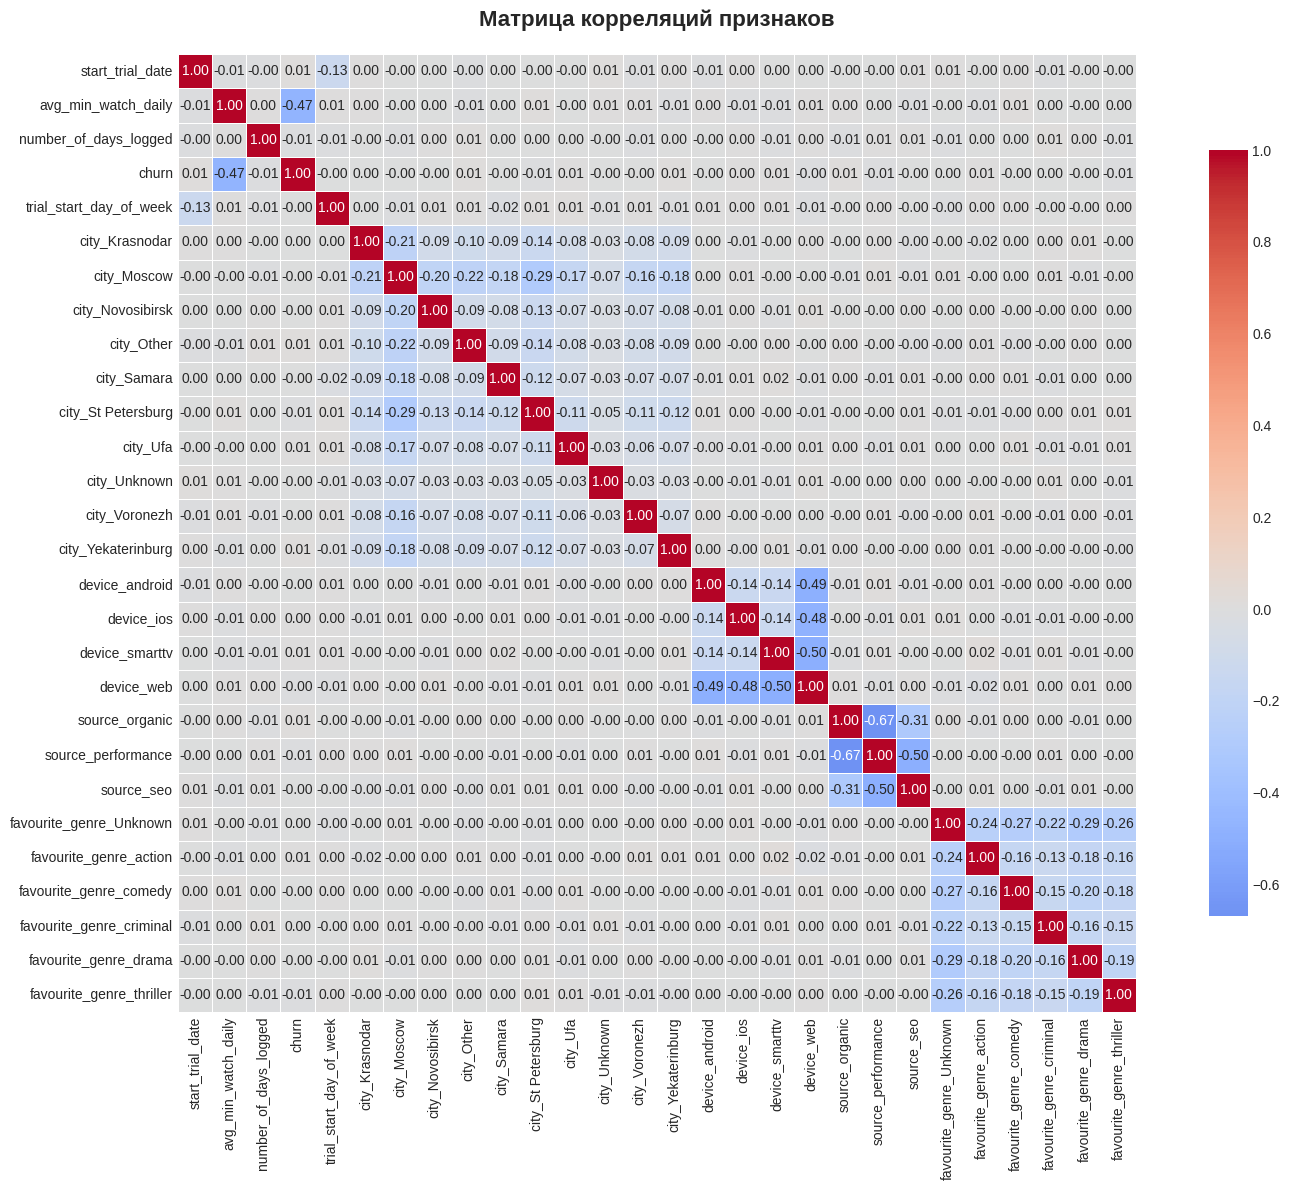

In [17]:
# Строим тепловую диаграмму
correlation_matrix = data_encoded.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Наблюдается **отрицательная корреляция** между **churn** и **avg_min_watch_daily** (-0.47) - чем больше время просмотров в день, тем меньше вероятность ухода

# Проанализируем как отток меняется в зависимости от среднего времени просмотра в день.

/tmp/ipython-input-1087797700.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))


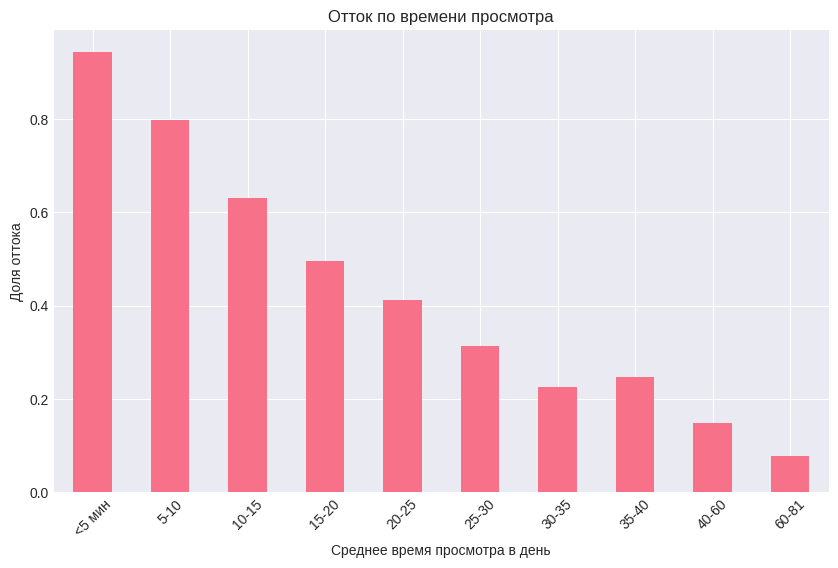

In [18]:
bins_minutes = [0, 5, 10, 15, 20, 25, 30, 35, 40, 60, 81]
labels = ['<5 мин', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-60', '60-81']

df['watch_category'] = pd.cut(df['avg_min_watch_daily'],
                               bins=bins_minutes,
                               labels=labels,
                               right=False)

df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))

plt.title('Отток по времени просмотра')
plt.ylabel('Доля оттока')
plt.xlabel('Среднее время просмотра в день')
plt.xticks(rotation=45)
plt.show()

## Гипотеза 1: Среднее время просмотра влияет на покупку

Чем выше среднее время просмотра в день, тем выше конверсия в подписку.

### Стратегия проверки

Разобьем на две группы:

1. те, кто совершил подписку
2. те, кто нет

Проверим, различаются ли статистически у них среднее время просмотра.

### Статистический метод

Тест Манна-Уитни

# Проанализируем какое минимальное время просмотра защищает от оттока

In [19]:
# Анализ пороговых значений для времени просмотра
threshold_analysis = []
for threshold in [5, 10, 15, 30, 60]:
    churn_below = df[df['avg_min_watch_daily'] < threshold]['churn'].mean()
    churn_above = df[df['avg_min_watch_daily'] >= threshold]['churn'].mean()
    threshold_analysis.append({
        'threshold': threshold,
        'churn_below': churn_below,
        'churn_above': churn_above,
        'diff': churn_below - churn_above
    })

threshold_df = pd.DataFrame(threshold_analysis)
print("\nАнализ порогов для времени просмотра:")
print(threshold_df)


Анализ порогов для времени просмотра:
   threshold  churn_below  churn_above      diff
0          5     0.944513     0.654175  0.290338
1         10     0.891101     0.508850  0.382252
2         15     0.853723     0.405466  0.448257
3         30     0.802102     0.205980  0.596122
4         60     0.789617     0.076923  0.712694


## Гипотеза 2. Порог ценности в 30 минут просмотра влияет на вероятность оттока

Порог 30 мин. Пользователи кто смотрит < 30 минут уходит в 80% случаев (не видит ценности), кто более 30 минут уходит в 20% случаев (видит ценность, возможно смотрит какой-то конкретный контент).

### Стратегия проверки

Разделим пользователей на 2 группы:
1. пользователи с avg_min_watch_daily < 30 минут
2. пользователи с avg_min_watch_daily ≥ 30 минут.

Проверим, различается ли статистически доля оттока в каждой группе.

### Статистический метод

Z-тест для пропорций (основной метод) и доверительные интервалы.

# Проанализируем как конверсия меняется в зависимости от количества дней логинов в триал

In [20]:
conversion_by_days = (
    df.groupby("number_of_days_logged")
      .apply(lambda x: 1 - x["churn"].mean())
      .reset_index(name="conversion_rate")
)

conversion_by_days

/tmp/ipython-input-1486672082.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: 1 - x["churn"].mean())


,number_of_days_logged,conversion_rate
0,1,0.207200
1,2,0.214069
2,3,0.211823
3,4,0.224903
4,5,0.204365
5,6,0.242481
6,7,0.212185


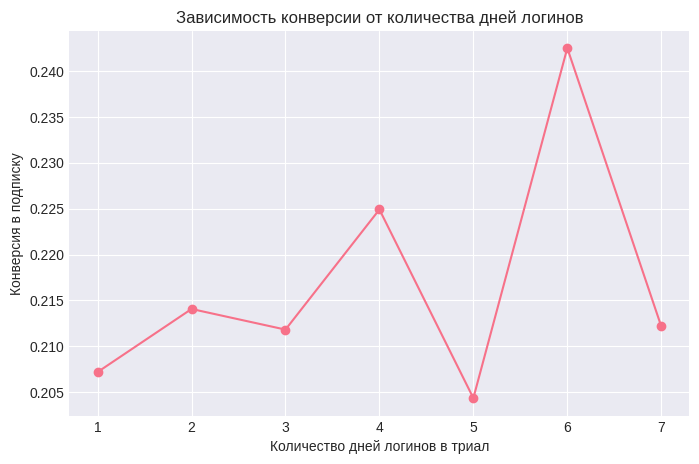

In [21]:
plt.figure(figsize=(8,5))
plt.plot(
    conversion_by_days["number_of_days_logged"],
    conversion_by_days["conversion_rate"],
    marker="o"
)

plt.xlabel("Количество дней логинов в триал")
plt.ylabel("Конверсия в подписку")
plt.title("Зависимость конверсии от количества дней логинов")
plt.grid(True)
plt.show()

Наблюдается **спад конверсии на 5 и 7 дни**. Люди теряют интерес или пользуются только пробным периодом, а затем уходят

## Гипотеза 3: Конверсия падает на 5-й день триала

**H0:** Снижение конверсии на 5-й день триала является случайным и не связано с особенностями поведения пользователей в середине триального периода.

**H1:** Снижение конверсии на 5-й день триала обусловлено тем, что пользователи, которые не нашли достаточно ценного контента к середине триала (имели низкую активность просмотра), отписываются за пару дней до окончания триала.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. те, которые были активны на 5-й день и совершили подписку
2. те, которые были активны на 5-й день и не совершили подписку.

Чтобы проверить, предсказывает ли активность перед спадом сам спад конверсии, проанализируем среднее время просмотра на 4-й день триала (день перед спадом).

### Статистический метод

Тест Манна-Уитни

Используется, поскольку является непараметрическим и не требует нормальности, а также устойчив к выбросам

In [29]:
import scipy.stats as stats

# Рассчитаем конверсию по дням активности
conversion_by_days = (
    df.groupby("number_of_days_logged")
      .agg(
          total_users=('user_id', 'count'),
          conversions=('churn', lambda x: (x == 0).sum()),
          conversion_rate=('churn', lambda x: (1 - x.mean()) * 100),
          avg_watch_time=('avg_min_watch_daily', 'mean')
      )
      .reset_index()
)

print("Конверсия и среднее время просмотра по дням активности:")
print(conversion_by_days.to_string())


# Сравним пользователей с 4 и 5 днями активности
users_4_days = df[df['number_of_days_logged'] == 4].copy()
users_5_days = df[df['number_of_days_logged'] == 5].copy()

print(f"\nПользователей с 4 днями активности: {len(users_4_days)}")
print(f"Пользователей с 5 днями активности: {len(users_5_days)}")

# Сравнение среднего времени просмотра между группами 4 и 5 дней
print(f"\nСравнение среднего времени просмотра:")
print(f"4 дня: {users_4_days['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"5 дней: {users_5_days['avg_min_watch_daily'].mean():.1f} мин/день")

# Тест Манна-Уитни для сравнения распределений
stat_4_5, p_4_5 = stats.mannwhitneyu(
    users_4_days['avg_min_watch_daily'].dropna(),
    users_5_days['avg_min_watch_daily'].dropna(),
    alternative='two-sided'
)

print(f"\nТест Манна-Уитни (4 дня vs 5 дней):")
print(f"p-value = {p_4_5:.5f}")
if p_4_5 < 0.05:
    print("Есть статистически значимая разница в среднем времени просмотра")
else:
    print("Нет статистически значимой разницы в среднем времени просмотра")

# Основной тест: сравнение вовлеченности внутри группы 5 дней
# Разделим пользователей с 5 днями активности на конвертированных и неконвертированных
users_5_converted = users_5_days[users_5_days['churn'] == 0]
users_5_not_converted = users_5_days[users_5_days['churn'] == 1]

print(f"\nАнализ внутри группы с 5 днями активности:")
print(f"Конвертировалось: {len(users_5_converted)} ({len(users_5_converted)/len(users_5_days)*100:.1f}%)")
print(f"Не конвертировалось: {len(users_5_not_converted)} ({len(users_5_not_converted)/len(users_5_days)*100:.1f}%)")
print(f"\nСреднее время просмотра:")
print(f"Конвертированные: {users_5_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Неконвертированные: {users_5_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")

# Тест Манна-Уитни для сравнения внутри группы 5 дней
stat_5_groups, p_5_groups = stats.mannwhitneyu(
    users_5_converted['avg_min_watch_daily'].dropna(),
    users_5_not_converted['avg_min_watch_daily'].dropna(),
    alternative='greater'
)

print(f"\nТест Манна-Уитни (внутри 5 дней, конвертированные vs неконвертированные):")
print(f"p-value = {p_5_groups:.5f}")
print(f"U-статистика = {stat_5_groups:.0f}")

if p_5_groups < 0.05:
    print("У конвертированных пользователей с 5 днями активности")
    print("среднее время просмотра статистически значимо выше")
else:
    print("Нет статистически значимой разницы во времени просмотра")
    print("между конвертированными и неконвертированными пользователями с 5 днями активности")

# Дополнительный анализ: сравним с пользователями, у которых 4 дня  и 6 дней активности
users_4_converted = users_4_days[users_4_days['churn'] == 0]
users_4_not_converted = users_4_days[users_4_days['churn'] == 1]

users_6_days = df[df['number_of_days_logged'] == 6].copy()
users_6_converted = users_6_days[users_6_days['churn'] == 0]
users_6_not_converted = users_6_days[users_6_days['churn'] == 1]


print(f"\nСравнение с пользователями 4 дней активности:")
print(f"Конвертированные (4 дня): {users_4_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Конвертированные (5 дней): {users_5_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Конвертированные (6 дней): {users_6_converted['avg_min_watch_daily'].mean():.1f} мин/день")

print(f"\nНеконвертированные (4 дня): {users_4_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Неконвертированные (5 дня): {users_5_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Неконвертированные (6 дня): {users_6_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")

Конверсия и среднее время просмотра по дням активности:
   number_of_days_logged  total_users  conversions  conversion_rate  avg_watch_time
0                      1        17360         3597        20.720046        7.780791
1                      2         4620          989        21.406926        7.854345
2                      3         2436          516        21.182266        7.927081
3                      4         1036          233        22.490347        7.841756
4                      5         1008          206        20.436508        7.519630
5                      6         1064          258        24.248120        8.068037
6                      7          476          101        21.218487        7.971326

Пользователей с 4 днями активности: 1036
Пользователей с 5 днями активности: 1008

Сравнение среднего времени просмотра:
4 дня: 7.8 мин/день
5 дней: 7.5 мин/день

Тест Манна-Уитни (4 дня vs 5 дней):
p-value = 0.48560
Нет статистически значимой разницы в среднем времени п

/tmp/ipython-input-1355628638.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax3.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)
/tmp/ipython-input-1355628638.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot_5 = ax4.boxplot(box_data_5, labels=labels_5, patch_artist=True, widths=0.6)
/tmp/ipython-input-1355628638.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_conversion = users_5_days.groupby('watch_bin')['churn'].mean().apply(lambda x: (1-x)*100)
/tmp/ipython-input-1355628638.py:101: FutureWarning: 


Анализ оптимального порога вовлеченности


Конверсия при разных порогах вовлеченности (для 5 дней активности):
   threshold  users_above  users_below  conv_above  conv_below       diff
0         10          248          760   48.790323   11.184211  37.606112
1         15          141          867   58.156028   14.302191  43.853837
2         20           62          946   72.580645   17.019027  55.561618
3         25           37          971   72.972973   18.434604  54.538369
4         30           19          989   78.947368   19.312437  59.634932

Оптимальный порог вовлеченности: 30.0 мин/день
   Конверсия выше порога: 78.9%
   Конверсия ниже порога: 19.3%
   Разница: +59.6%


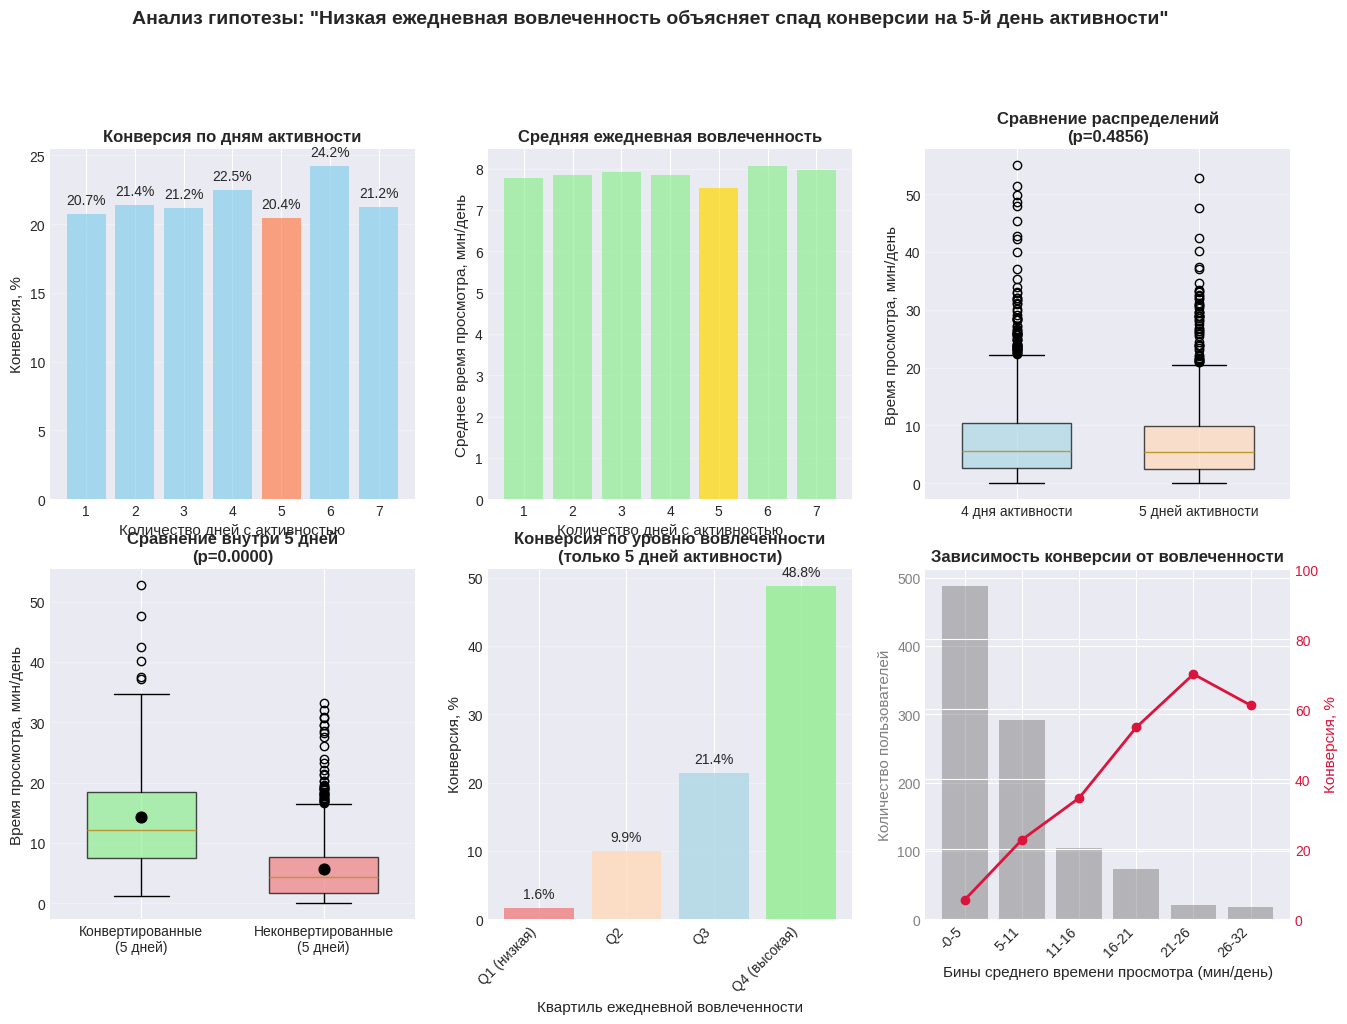

In [31]:
# Создадим визуализацию
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Анализ гипотезы: "Низкая ежедневная вовлеченность объясняет спад конверсии на 5-й день активности"',
             fontsize=14, fontweight='bold', y=1.02)

# График 1: Конверсия по дням активности
ax1 = axes[0, 0]
bars = ax1.bar(conversion_by_days['number_of_days_logged'],
               conversion_by_days['conversion_rate'],
               color=['skyblue' if x != 5 else 'coral' for x in conversion_by_days['number_of_days_logged']],
               alpha=0.7)
ax1.set_xlabel("Количество дней с активностью", fontsize=11)
ax1.set_ylabel("Конверсия, %", fontsize=11)
ax1.set_title("Конверсия по дням активности", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, conv in zip(bars, conversion_by_days['conversion_rate']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{conv:.1f}%', ha='center', va='bottom', fontsize=10)

# График 2: Среднее время просмотра по дням активности
ax2 = axes[0, 1]
ax2.bar(conversion_by_days['number_of_days_logged'],
        conversion_by_days['avg_watch_time'],
        color=['lightgreen' if x != 5 else 'gold' for x in conversion_by_days['number_of_days_logged']],
        alpha=0.7)
ax2.set_xlabel("Количество дней с активностью", fontsize=11)
ax2.set_ylabel("Среднее время просмотра, мин/день", fontsize=11)
ax2.set_title("Средняя ежедневная вовлеченность", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# График 3: Сравнение распределений времени просмотра (4 vs 5 дней)
ax3 = axes[0, 2]

box_data = [users_4_days['avg_min_watch_daily'].dropna(),
            users_5_days['avg_min_watch_daily'].dropna()]
labels = ['4 дня активности', '5 дней активности']
boxplot = ax3.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)

colors_box = ['lightblue', 'peachpuff']
for patch, color in zip(boxplot['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel("Время просмотра, мин/день", fontsize=11)
ax3.set_title(f"Сравнение распределений\n(p={p_4_5:.4f})", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# График 4: Сравнение внутри группы 5 дней
ax4 = axes[1, 0]

box_data_5 = [users_5_converted['avg_min_watch_daily'].dropna(),
              users_5_not_converted['avg_min_watch_daily'].dropna()]
labels_5 = ['Конвертированные\n(5 дней)', 'Неконвертированные\n(5 дней)']
boxplot_5 = ax4.boxplot(box_data_5, labels=labels_5, patch_artist=True, widths=0.6)

colors_5 = ['lightgreen', 'lightcoral']
for patch, color in zip(boxplot_5['boxes'], colors_5):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate(box_data_5, 1):
    mean_val = np.mean(data)
    ax4.scatter(i, mean_val, color='black', zorder=3, s=60)

ax4.set_ylabel("Время просмотра, мин/день", fontsize=11)
ax4.set_title(f"Сравнение внутри 5 дней\n(p={p_5_groups:.4f})", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# График 5: Зависимость конверсии от времени просмотра для 5 дней
ax5 = axes[1, 1]

users_5_days['watch_bin'] = pd.qcut(users_5_days['avg_min_watch_daily'],
                                     q=4,
                                     labels=['Q1 (низкая)', 'Q2', 'Q3', 'Q4 (высокая)'])
bin_conversion = users_5_days.groupby('watch_bin')['churn'].mean().apply(lambda x: (1-x)*100)

colors_bin = ['lightcoral', 'peachpuff', 'lightblue', 'lightgreen']
bars_bin = ax5.bar(range(len(bin_conversion)), bin_conversion, color=colors_bin, alpha=0.8)

ax5.set_xlabel("Квартиль ежедневной вовлеченности", fontsize=11)
ax5.set_ylabel("Конверсия, %", fontsize=11)
ax5.set_title("Конверсия по уровню вовлеченности\n(только 5 дней активности)",
              fontsize=12, fontweight='bold')
ax5.set_xticks(range(len(bin_conversion)))
ax5.set_xticklabels(bin_conversion.index, rotation=45, ha='right')
ax5.grid(True, alpha=0.3, axis='y')

for bar, conv in zip(bars_bin, bin_conversion):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{conv:.1f}%', ha='center', va='bottom', fontsize=10)

# График 6: Совместная визуализация конверсии и вовлеченности

ax6 = axes[1, 2]

engagement_bins_series = pd.cut(users_5_days['avg_min_watch_daily'], bins=10)

grouped = users_5_days.groupby(engagement_bins_series).agg(
    conversion_rate=('churn', lambda x: (1 - x.mean()) * 100),
    avg_engagement=('avg_min_watch_daily', 'mean'),
    count=('user_id', 'count')
).reset_index()

grouped = grouped.rename(columns={'avg_min_watch_daily': 'engagement_bins'})

grouped = grouped[grouped['count'] > 10]

ax6_bar = ax6.bar(range(len(grouped)), grouped['count'],
                  alpha=0.5, color='gray', label='Количество пользователей')
ax6.set_xlabel("Бины среднего времени просмотра (мин/день)", fontsize=11)
ax6.set_ylabel("Количество пользователей", fontsize=11, color='gray')
ax6.tick_params(axis='y', labelcolor='gray')

ax6_line = ax6.twinx()
ax6_line.plot(range(len(grouped)), grouped['conversion_rate'],
              color='crimson', marker='o', linewidth=2, markersize=6,
              label='Конверсия, %')
ax6_line.set_ylabel("Конверсия, %", fontsize=11, color='crimson')
ax6_line.tick_params(axis='y', labelcolor='crimson')
ax6_line.set_ylim(0, 100)

ax6.set_xticks(range(len(grouped)))
ax6.set_xticklabels([f"{interval.left:.0f}-{interval.right:.0f}"
                     for interval in grouped['engagement_bins']],
                    rotation=45, ha='right')

ax6.set_title("Зависимость конверсии от вовлеченности", fontsize=12, fontweight='bold')


# Поиск оптимального порога вовлеченности
print("\nАнализ оптимального порога вовлеченности\n")

# Создаем различные пороги и смотрим конверсию
thresholds = [10, 15, 20, 25, 30, 40, 50]
results = []

for threshold in thresholds:
    above_threshold = users_5_days[users_5_days['avg_min_watch_daily'] >= threshold]
    below_threshold = users_5_days[users_5_days['avg_min_watch_daily'] < threshold]

    if len(above_threshold) > 10 and len(below_threshold) > 10:
        conv_above = (1 - above_threshold['churn'].mean()) * 100
        conv_below = (1 - below_threshold['churn'].mean()) * 100

        results.append({
            'threshold': threshold,
            'users_above': len(above_threshold),
            'users_below': len(below_threshold),
            'conv_above': conv_above,
            'conv_below': conv_below,
            'diff': conv_above - conv_below
        })

results_df = pd.DataFrame(results)
print("\nКонверсия при разных порогах вовлеченности (для 5 дней активности):")
print(results_df.to_string())

# Находим оптимальный порог
if not results_df.empty:
    optimal = results_df.loc[results_df['diff'].idxmax()]
    print(f"\nОптимальный порог вовлеченности: {optimal['threshold']} мин/день")
    print(f"   Конверсия выше порога: {optimal['conv_above']:.1f}%")
    print(f"   Конверсия ниже порога: {optimal['conv_below']:.1f}%")
    print(f"   Разница: +{optimal['diff']:.1f}%")


Проведем дополнительный анализ: почему именно 5 дней?


1. Расределение пользователей с 5 днями активности на оставшихся и ушедших:
Всего пользователей с 5 днями активности: 1008
Из них подписались: 206 (20.4%)
Из них не подписались: 802 (79.6%)

2. Критический порог вовлеченности:
Медианная вовлеченность неконвертированных: 4.4 мин/день
Неконвертированных с вовлеченностью ≥12 мин: 96
Из них могли бы конвертироваться: ~12.0%

3. СРАВНЕНИЕ ПО ДНЯМ АКТИВНОСТИ:
3 дней: Конверсия=21.2%, Среднее=7.9 мин, Конверт=14.9 мин, Не конверт=6.0 мин
4 дней: Конверсия=22.5%, Среднее=7.8 мин, Конверт=14.9 мин, Не конверт=5.8 мин
5 дней: Конверсия=20.4%, Среднее=7.5 мин, Конверт=14.3 мин, Не конверт=5.8 мин
6 дней: Конверсия=24.2%, Среднее=8.1 мин, Конверт=15.0 мин, Не конверт=5.8 мин
7 дней: Конверсия=21.2%, Среднее=8.0 мин, Конверт=15.3 мин, Не конверт=6.0 мин


/tmp/ipython-input-4037261499.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = users_5_days.groupby('engagement_group').agg(


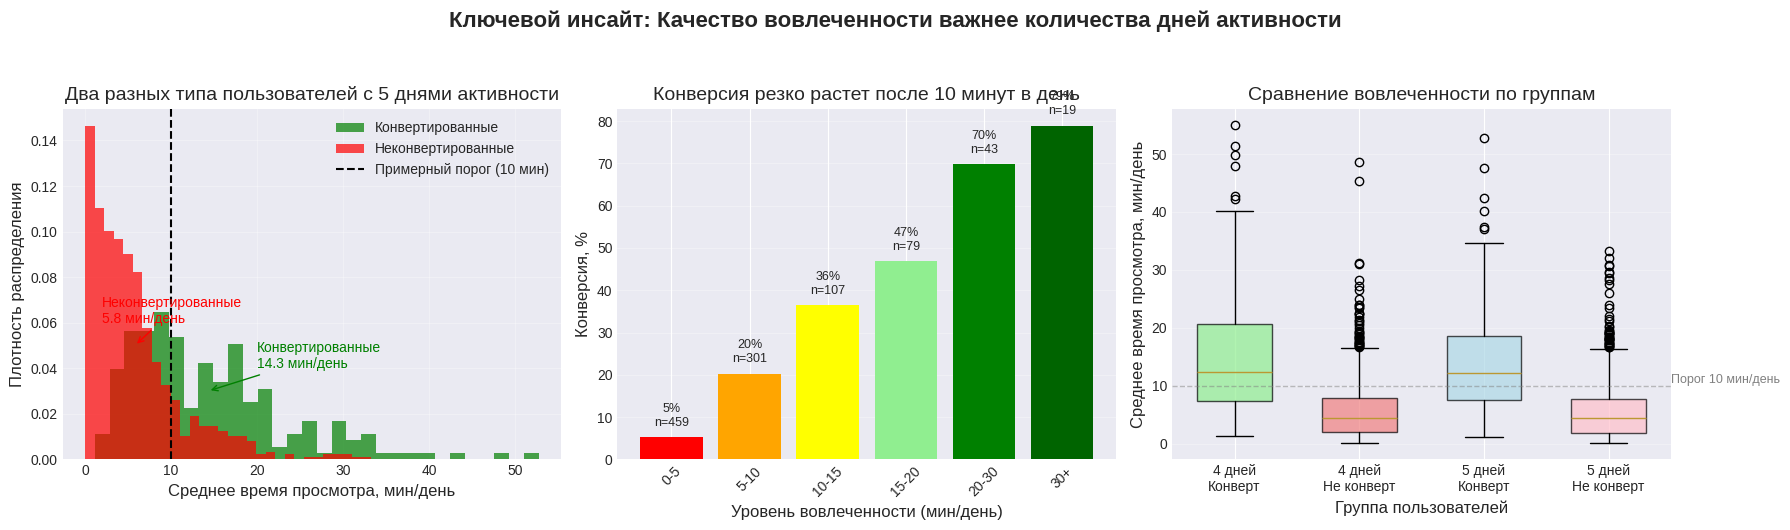

In [33]:
# 1. Анализ распределения
print("\n1. Расределение пользователей с 5 днями активности на оставшихся и ушедших:")
print(f"Всего пользователей с 5 днями активности: {len(users_5_days)}")
print(f"Из них подписались: {len(users_5_converted)} ({len(users_5_converted)/len(users_5_days)*100:.1f}%)")
print(f"Из них не подписались: {len(users_5_not_converted)} ({len(users_5_not_converted)/len(users_5_days)*100:.1f}%)")

# 2. Анализ порога вовлеченности
print("\n2. Критический порог вовлеченности:")

# Рассчитаем медиану среднего минимального просмотра для не подписавшихся
median_not_converted = users_5_not_converted['avg_min_watch_daily'].median()
print(f"Медианная вовлеченность неконвертированных: {median_not_converted:.1f} мин/день")

# Сколько не подписавшихся с медианой выше медианы под?
converted_median = users_5_converted['avg_min_watch_daily'].median()
not_converted_above_threshold = users_5_not_converted[users_5_not_converted['avg_min_watch_daily'] >= converted_median]
print(f"Неконвертированных с вовлеченностью ≥{converted_median:.0f} мин: {len(not_converted_above_threshold)}")
print(f"Из них могли бы конвертироваться: ~{len(not_converted_above_threshold)/len(users_5_not_converted)*100:.1f}%")

# 3. Сравнение с другими днями активности
print("\n3. СРАВНЕНИЕ ПО ДНЯМ АКТИВНОСТИ:")
for days in [3, 4, 5, 6, 7]:
    users_days = df[df['number_of_days_logged'] == days]
    if len(users_days) > 0:
        conv_rate = (1 - users_days['churn'].mean()) * 100
        avg_watch = users_days['avg_min_watch_daily'].mean()
        conv_watch = users_days[users_days['churn'] == 0]['avg_min_watch_daily'].mean()
        not_conv_watch = users_days[users_days['churn'] == 1]['avg_min_watch_daily'].mean()

        print(f"{days} дней: Конверсия={conv_rate:.1f}%, "
              f"Среднее={avg_watch:.1f} мин, "
              f"Конверт={conv_watch:.1f} мин, "
              f"Не конверт={not_conv_watch:.1f} мин")

# Создаем финальную визуализацию
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ключевой инсайт: Качество вовлеченности важнее количества дней активности',
             fontsize=16, fontweight='bold', y=1.05)

# График 1: Две разные группы внутри 5 дней
ax1 = axes[0]
# Гистограмма распределения
ax1.hist(users_5_converted['avg_min_watch_daily'], bins=30, alpha=0.7,
         color='green', label='Конвертированные', density=True)
ax1.hist(users_5_not_converted['avg_min_watch_daily'], bins=30, alpha=0.7,
         color='red', label='Неконвертированные', density=True)
ax1.axvline(x=10, color='black', linestyle='--', linewidth=1.5,
           label='Примерный порог (10 мин)')
ax1.set_xlabel('Среднее время просмотра, мин/день', fontsize=12)
ax1.set_ylabel('Плотность распределения', fontsize=12)
ax1.set_title('Два разных типа пользователей с 5 днями активности', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Добавляем аннотации
ax1.annotate(f'Конвертированные\n14.3 мин/день',
             xy=(14.3, 0.03), xytext=(20, 0.04),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')
ax1.annotate(f'Неконвертированные\n5.8 мин/день',
             xy=(5.8, 0.05), xytext=(2, 0.06),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

# График 2: Сравнение конверсии по уровню вовлеченности
ax2 = axes[1]

users_5_days['engagement_group'] = pd.cut(users_5_days['avg_min_watch_daily'],
                                          bins=[0, 5, 10, 15, 20, 30, 100],
                                          labels=['0-5', '5-10', '10-15', '15-20', '20-30', '30+'])
group_stats = users_5_days.groupby('engagement_group').agg(
    conversion_rate=('churn', lambda x: (1 - x.mean()) * 100),
    user_count=('user_id', 'count')
).reset_index()

group_stats = group_stats[group_stats['user_count'] > 10]

bars = ax2.bar(range(len(group_stats)), group_stats['conversion_rate'],
               color=['red', 'orange', 'yellow', 'lightgreen', 'green', 'darkgreen'])
ax2.set_xlabel('Уровень вовлеченности (мин/день)', fontsize=12)
ax2.set_ylabel('Конверсия, %', fontsize=12)
ax2.set_title('Конверсия резко растет после 10 минут в день', fontsize=14)
ax2.set_xticks(range(len(group_stats)))
ax2.set_xticklabels(group_stats['engagement_group'], rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

for i, (bar, conv, count) in enumerate(zip(bars, group_stats['conversion_rate'], group_stats['user_count'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{conv:.0f}%\nn={count}', ha='center', va='bottom', fontsize=9)

# График 3: Сравнение всех групп
ax3 = axes[2]

data_to_plot = []
labels = []

for days in [4, 5]:
    for churn_status in [0, 1]:
        subset = df[(df['number_of_days_logged'] == days) & (df['churn'] == churn_status)]
        if len(subset) > 10:
            data_to_plot.append(subset['avg_min_watch_daily'].dropna())
            status_name = 'Конверт' if churn_status == 0 else 'Не конверт'
            labels.append(f'{days} дней\n{status_name}')

positions = range(1, len(data_to_plot) + 1)
boxplot = ax3.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True)

colors = ['lightgreen', 'lightcoral', 'lightblue', 'pink']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Группа пользователей', fontsize=12)
ax3.set_ylabel('Среднее время просмотра, мин/день', fontsize=12)
ax3.set_title('Сравнение вовлеченности по группам', fontsize=14)
ax3.set_xticks(positions)
ax3.set_xticklabels(labels, rotation=0)
ax3.grid(True, alpha=0.3, axis='y')

ax3.axhline(y=10, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.text(4.5, 10.5, 'Порог 10 мин/день', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# **Вывод**

Гипотеза H1 потверждена

Тест Манна-Уитни (внутри 5 дней, конвертированные vs неконвертированные):

p-value = 0.00000

U-статистика = 136143

У конвертированных пользователей с 5 днями активности
среднее время просмотра статистически значимо выше


Фактически обнаружено:
1. Количество дней активности само по себе не определяет конверсию
2. Ключевой фактор - КАЧЕСТВО использования (среднее время просмотра в день)
3. Пользователи с 5 днями активности делятся на две группы:

   • Глубоко вовлеченные (14+ мин/день) → конвертируются хорошо

   • Поверхностно вовлеченные (~6 мин/день) → конвертируются плохо

Рекомендуемые действия:
1. Сфокусироваться на увеличении глубины вовлеченности, а не частоты посещений
2. Внедрить систему early warning для пользователей с низкой ежедневной вовлеченностью
3. Оптимизировать подрорку контента пользователей в первые 3-4 дня триала

# Проанализируем связь географии (городов), времени просмотров пользователей и отток

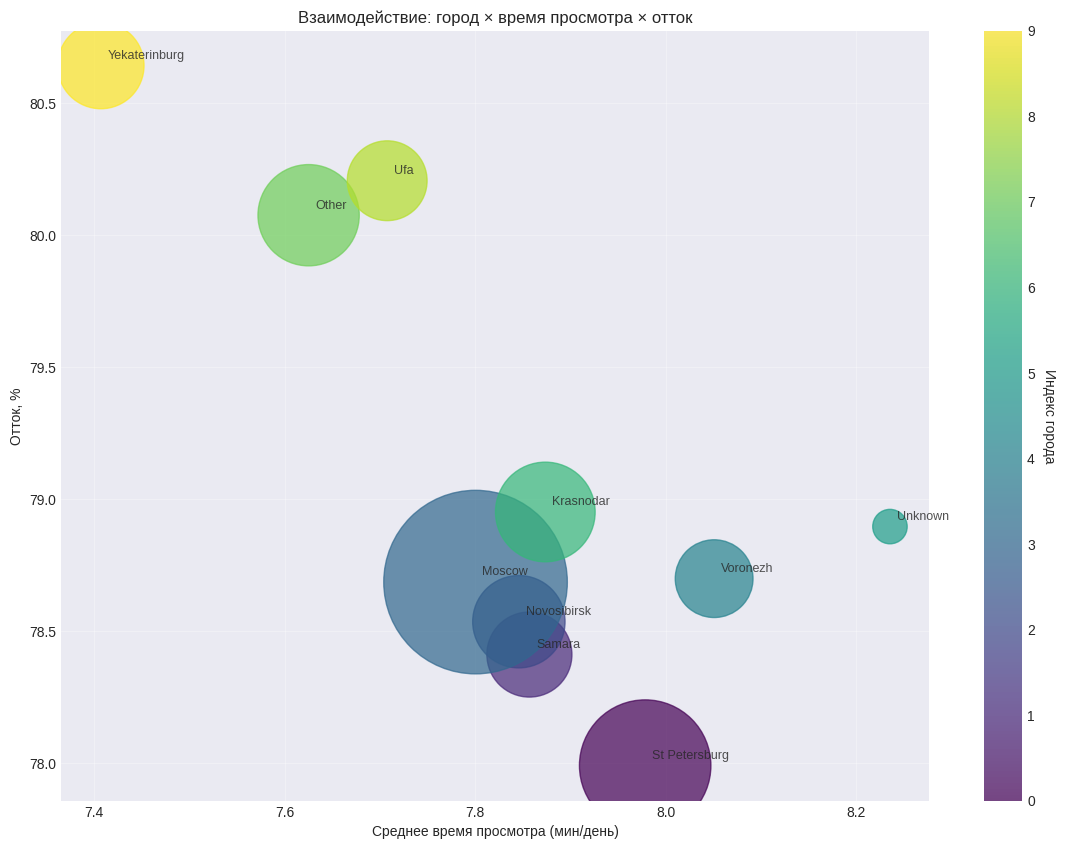

In [25]:
# График зависимости город х время просмотра х отток
city_watch_interaction = df.groupby('city').agg({
    'churn': 'mean',
    'avg_min_watch_daily': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'count', 'churn': 'churn_rate'})

city_watch_interaction['churn_rate_percent'] = city_watch_interaction['churn_rate'] * 100
city_watch_interaction = city_watch_interaction.sort_values('churn_rate_percent')

plt.figure(figsize=(14, 10))

scatter = plt.scatter(city_watch_interaction['avg_min_watch_daily'],
                            city_watch_interaction['churn_rate_percent'],
                            s=city_watch_interaction['count']*2,
                            alpha=0.7,
                            c=range(len(city_watch_interaction)),
                            cmap='viridis')

for city, row in city_watch_interaction.iterrows():
   plt.annotate(city,
                       xy=(row['avg_min_watch_daily'], row['churn_rate_percent']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.8)

plt.xlabel('Среднее время просмотра (мин/день)')
plt.ylabel('Отток, %')
plt.title('Взаимодействие: город × время просмотра × отток')
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Индекс города', rotation=270, labelpad=15)

## Гипотеза 4: Географический фактор влияет на отток

Географический фактор (город) является значимым предиктором оттока. Пользователи в Екатеринбурге и Уфе демонстрируют паттерны поведения, отличные от других регионов: меньшее время просмотра при более высоком оттоке.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. из Екатеринбурга и Уфы (проблемные города)
2. из остальных городов

### Статистический метод

Сравнение времени просмотра между группами - тест Манна-Уитни, оттока - Z-тест для пропорций.